In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, classification_report

%pip install xgboost
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Dataset Extraction

In [2]:
df = pd.read_csv('Premier_League.csv')

In [3]:
df.head()

,date,clock,stadium,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
0,28th May 2023,4:30pm,Emirates Stadium,"60,095",Arsenal,5,Wolverhampton Wanderers,0,51.0,49.0,...,52.2,0,3,8,11,0,0,0,0,https://www.skysports.com/football/arsenal-vs-...
1,28th May 2023,4:30pm,Villa Park,"42,212",Aston Villa,2,Brighton and Hove Albion,1,40.3,59.7,...,47.8,3,3,15,16,4,4,0,0,https://www.skysports.com/football/aston-villa...
2,28th May 2023,4:30pm,Gtech Community Stadium,"17,120",Brentford,1,Manchester City,0,34.4,65.6,...,50.0,2,3,12,8,4,0,0,0,https://www.skysports.com/football/brentford-v...
3,28th May 2023,4:30pm,Stamford Bridge,"40,130",Chelsea,1,Newcastle United,1,64.4,35.6,...,45.5,3,5,9,11,0,0,0,0,https://www.skysports.com/football/chelsea-vs-...
4,28th May 2023,4:30pm,Selhurst Park,"25,198",Crystal Palace,1,Nottingham Forest,1,66.0,34.0,...,41.7,3,2,9,13,0,2,0,0,https://www.skysports.com/football/crystal-pal...


In [4]:
df.shape

(380, 39)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 39 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              380 non-null    object 
 1   clock             380 non-null    object 
 2   stadium           380 non-null    object 
 3   attendance        380 non-null    object 
 4   Home Team         380 non-null    object 
 5   Goals Home        380 non-null    int64  
 6   Away Team         380 non-null    object 
 7   Away Goals        380 non-null    int64  
 8   home_possessions  380 non-null    float64
 9   away_possessions  380 non-null    float64
 10  home_shots        380 non-null    int64  
 11  away_shots        380 non-null    int64  
 12  home_on           380 non-null    int64  
 13  away_on           380 non-null    int64  
 14  home_off          380 non-null    int64  
 15  away_off          380 non-null    int64  
 16  home_blocked      380 non-null    int64  
 1

# Exploratory Data Analysis

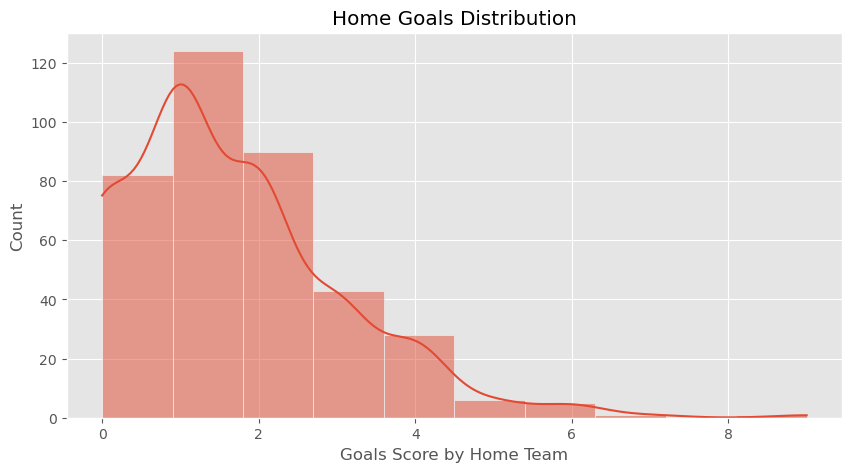

In [6]:
# Home Goal Distribution
plt.figure(figsize = (10, 5))
sns.histplot(df['Goals Home'], bins = 10, kde = True)
plt.title('Home Goals Distribution')
plt.xlabel('Goals Score by Home Team')
plt.ylabel('Count')
plt.grid(True)
plt.show()

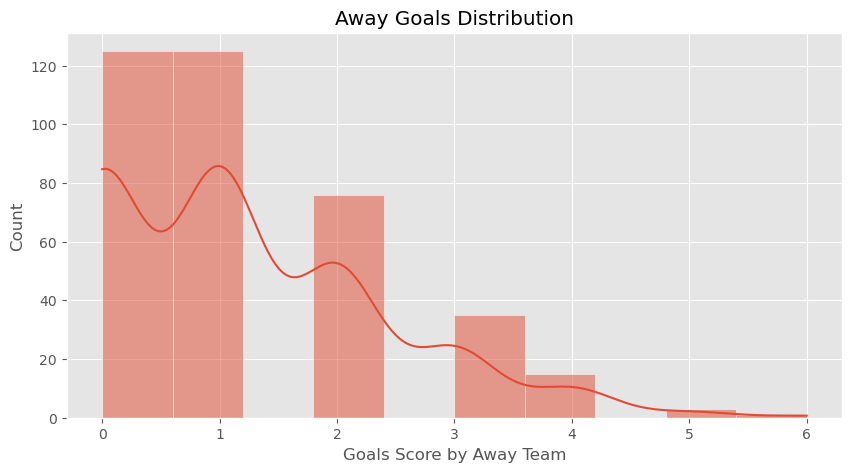

In [7]:
# Away Goals Distribution
plt.figure(figsize = (10, 5))
sns.histplot(df['Away Goals'], bins = 10, kde = True)
plt.title('Away Goals Distribution')
plt.xlabel('Goals Score by Away Team')
plt.ylabel('Count')
plt.grid(True)
plt.show()

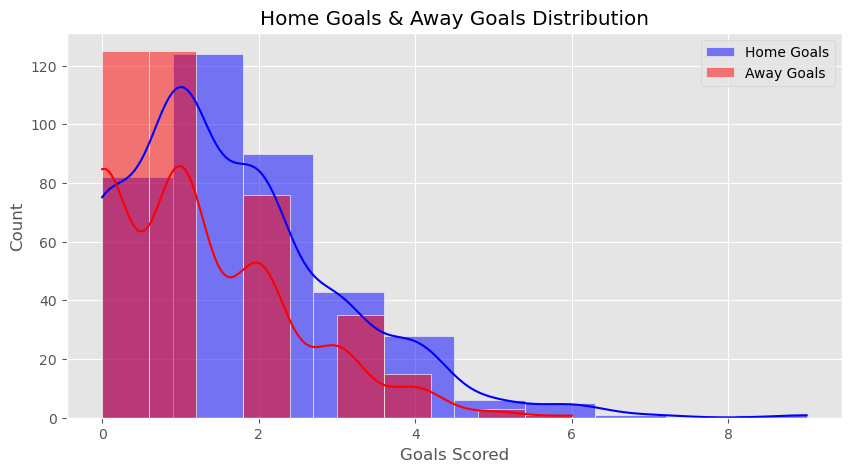

In [8]:
# Distribution of Home and Away Goals
plt.figure(figsize = (10, 5))
sns.histplot(df['Goals Home'], bins = 10, kde = True, color = 'blue', label = 'Home Goals')
sns.histplot(df['Away Goals'], bins = 10, kde = True, color = 'red', label = 'Away Goals')
plt.title('Home Goals & Away Goals Distribution')
plt.xlabel('Goals Scored')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

Histogram shows that home team makes the most goal throughout the year

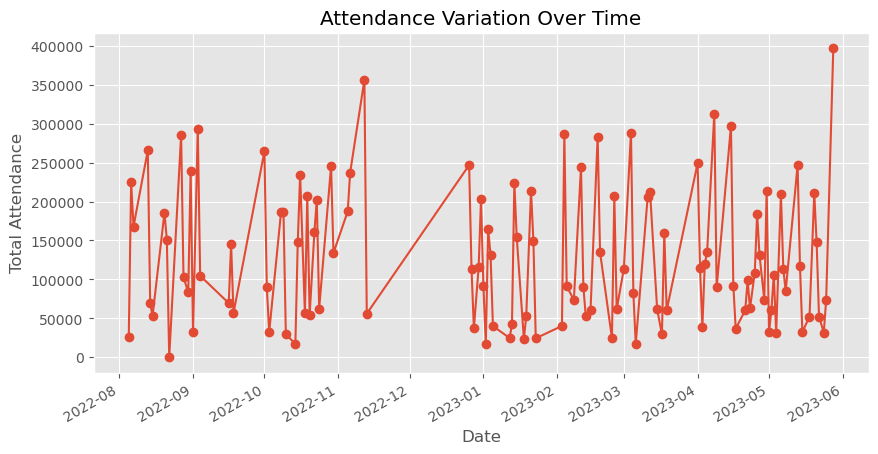

In [9]:
# Attendance Variation over time
df['date'] = pd.to_datetime(df['date'], format='mixed')
df['attendance'] = df['attendance'].astype(str).str.replace(',', '').str.replace('Nan', '0').astype(int) # Take out the , from the attendance and convert to integer
attendance_overtime = df.groupby('date')['attendance'].sum()

plt.figure(figsize = (10, 5))
attendance_overtime.plot(kind = 'line', marker = 'o')
plt.title('Attendance Variation Over Time')
plt.xlabel('Date')
plt.ylabel('Total Attendance')
plt.grid(True)
plt.show()

Attendance peaked between 2022-11 & 2022-12. The highest peaked at the end of 2023-06

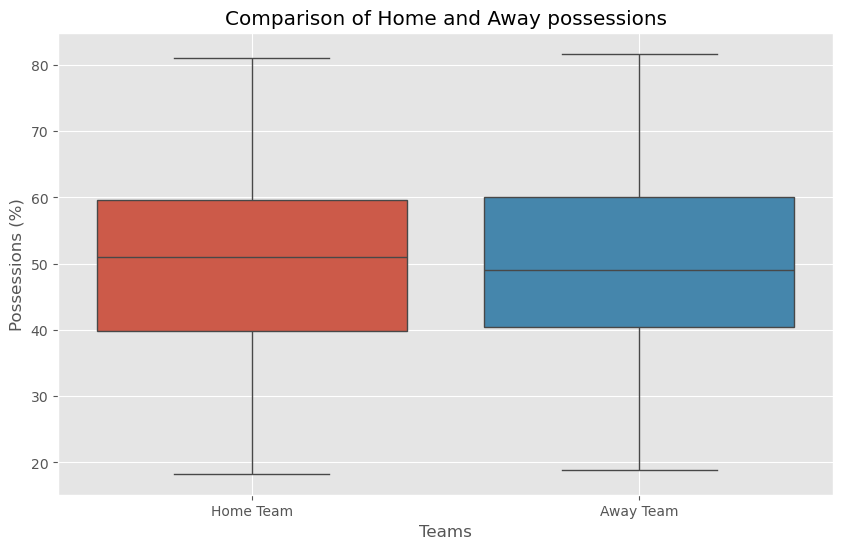

In [10]:
# Comparison of Home and Away possessions
plt.figure(figsize = (10, 6))
sns.boxplot(df[['home_possessions', 'away_possessions']])
plt.title('Comparison of Home and Away possessions')
plt.xlabel('Teams')
plt.ylabel('Possessions (%)')
plt.xticks(ticks = [0, 1], labels = ['Home Team', 'Away Team'])
plt.grid(True)
plt.show()

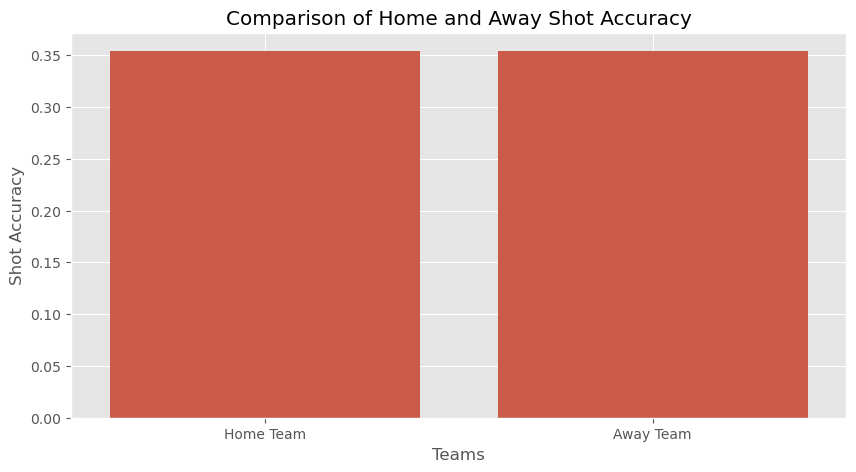

In [11]:
# Comparing Home and Away Shot Accuracy
df['home_shot_accuracy'] = df['home_on'] / df['home_shots']
df['away_shot_accuracy'] = df['away_on'] / df['away_shots']

plt.figure(figsize = (10, 5))
sns.barplot(x = ['Home Team', 'Away Team'], y = [df['home_shot_accuracy'].mean(), df['away_shot_accuracy'].mean()])
plt.title('Comparison of Home and Away Shot Accuracy')
plt.xlabel('Teams')
plt.ylabel('Shot Accuracy')
plt.grid(True)
plt.show()

# Feature Engineering

### Data cleaning & Label Encoding

In [12]:
# Drop irrelevant columns
df = df.drop(columns=['clock', 'stadium', 'attendance', 'links'])

In [13]:
# Convert date to numerical feature
df['date'] = pd.to_datetime(df['date'])
df['day_of_year'] = df['date'].dt.dayofyear

In [14]:
# Calculate goal difference and home team win percentage
df['goal_difference'] = df['Goals Home'] - df['Away Goals']
df['home_team_win'] = df['goal_difference'].apply(lambda x: 1 if x > 0 else 0)
df['result'] = np.select(
    [df['goal_difference'] > 0, df['goal_difference'] == 0],
    [1, 0],
    default=-1)

In [15]:
# Encode Team Names to categorical columns
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Home Team'] = label_encoder.fit_transform(df['Home Team'])
df['Away Team'] = label_encoder.fit_transform(df['Away Team'])

In [16]:
df.head()

,date,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,...,home_yellow,away_yellow,home_red,away_red,home_shot_accuracy,away_shot_accuracy,day_of_year,goal_difference,home_team_win,result
0,2023-05-28,0,5,19,0,51.0,49.0,14,6,8,...,0,0,0,0,0.571429,0.000000,148,5,1,1
1,2023-05-28,1,2,4,1,40.3,59.7,12,8,5,...,4,4,0,0,0.416667,0.500000,148,1,1,1
2,2023-05-28,3,1,12,0,34.4,65.6,11,17,4,...,4,0,0,0,0.363636,0.176471,148,1,1,1
3,2023-05-28,5,1,14,1,64.4,35.6,22,13,5,...,0,0,0,0,0.227273,0.307692,148,0,0,0
4,2023-05-28,6,1,15,1,66.0,34.0,15,7,3,...,0,2,0,0,0.200000,0.571429,148,0,0,0


### Rolling Expected Goals (last 5 seasons)

In [17]:
# An approximate expected goals
df['home_xG_proxy'] = df['home_on'] * 0.15 + df['home_off'] * 0.05
df['away_xG_proxy'] = df['away_on'] * 0.15 + df['away_off'] * 0.05

In [18]:
# Home Team data
home = df[['date', 'Home Team', 'home_xG_proxy']].copy()
home.columns = ['date', 'Team', 'xG']

# Away Team data
away = df[['date', 'Away Team', 'away_xG_proxy']].copy()
away.columns = ['date', 'Team', 'xG']

team_df = pd.concat([home, away])

In [19]:
team_df = team_df.sort_values(by = 'date')

In [20]:
# 1. Reset the index to make it unique
team_df = team_df.reset_index(drop=True)

# 2. Run your original code
team_df["rolling_avg_xG"] = (
    team_df.groupby("Team")["xG"]
    .rolling(window=5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [21]:
team_df

,date,Team,xG,rolling_avg_xG
0,2022-08-05,6,0.40,NaN
1,2022-08-05,0,0.50,NaN
2,2022-08-06,5,1.05,NaN
3,2022-08-06,16,0.55,NaN
4,2022-08-06,15,0.15,NaN
...,...,...,...,...
755,2023-05-28,2,0.45,0.64
756,2023-05-28,17,1.20,0.98
757,2023-05-28,18,0.90,0.87
758,2023-05-28,11,1.75,1.11


In [22]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_xG']], left_on=['date', 'Home Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_xG': 'home_rolling_avg_xG'}).drop(columns=['Team'])

df = df.merge(team_df[['date', 'Team', 'rolling_avg_xG']], left_on=['date', 'Away Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_xG': 'away_rolling_avg_xG'}).drop(columns=['Team'])

In [23]:
df.dropna(inplace = True)

### Rolling Average for possessions (last 5 seasons)

In [24]:
# Home Team data
home = df[['date', 'Home Team', 'home_possessions']].copy()
home.columns = ['date', 'Team', 'Possessions']

# Away Team data
away = df[['date', 'Away Team', 'away_possessions']].copy()
away.columns = ['date', 'Team', 'Possessions']

team_df = pd.concat([home, away])

In [25]:
team_df = team_df.sort_values(by = 'date')

In [26]:
# 1. Reset the index to make it unique
team_df = team_df.reset_index(drop=True)

# 2. Run your original code
team_df["rolling_avg_possessions"] = (
    team_df.groupby("Team")["Possessions"]
    .rolling(window=5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [27]:
team_df

,date,Team,Possessions,rolling_avg_possessions
0,2022-08-30,9,69.1,NaN
1,2022-08-30,4,60.9,NaN
2,2022-08-30,3,51.1,NaN
3,2022-08-30,5,67.8,NaN
4,2022-08-30,16,32.2,NaN
...,...,...,...,...
675,2023-05-28,7,37.8,37.68
676,2023-05-28,9,52.1,41.28
677,2023-05-28,16,30.9,40.84
678,2023-05-28,11,69.1,62.66


Empty rolling averages present. Remove them.

Merge RA to original dataset

In [28]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_possessions']], left_on=['date', 'Home Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_possessions': 'home_rolling_avg_possessions'}).drop(columns=['Team'])

In [29]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_possessions']], left_on=['date', 'Away Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_possessions': 'away_rolling_avg_possessions'}).drop(columns=['Team'])

In [30]:
df

,date,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,...,day_of_year,goal_difference,home_team_win,result,home_xG_proxy,away_xG_proxy,home_rolling_avg_xG,away_rolling_avg_xG,home_rolling_avg_possessions,away_rolling_avg_possessions
0,2023-05-28,0,5,19,0,51.0,49.0,14,6,8,...,148,5,1,1,1.40,0.20,1.11,0.49,54.82,47.00
1,2023-05-28,1,2,4,1,40.3,59.7,12,8,5,...,148,1,1,1,1.00,0.75,0.67,1.09,45.52,57.54
2,2023-05-28,3,1,12,0,34.4,65.6,11,17,4,...,148,1,1,1,0.80,0.75,1.06,0.89,48.14,66.94
3,2023-05-28,5,1,14,1,64.4,35.6,22,13,5,...,148,0,0,0,1.20,0.85,1.07,1.16,60.16,53.02
4,2023-05-28,6,1,15,1,66.0,34.0,15,7,3,...,148,0,0,0,0.85,0.70,0.88,0.61,55.74,28.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,2022-08-31,11,2,14,1,71.8,28.2,23,5,6,...,243,1,1,1,1.30,0.45,1.29,0.96,NaN,NaN
336,2022-08-30,6,1,3,1,48.9,51.1,13,9,4,...,242,0,0,0,0.90,0.70,0.77,0.95,NaN,NaN
337,2022-08-30,8,2,4,1,39.1,60.9,10,7,3,...,242,1,1,1,0.80,0.75,0.87,0.88,NaN,NaN
338,2022-08-30,16,2,5,1,32.2,67.8,9,10,7,...,242,1,1,1,1.05,0.70,0.90,0.76,NaN,NaN


In [31]:
df.isnull().sum()

date                             0
Home Team                        0
Goals Home                       0
Away Team                        0
Away Goals                       0
home_possessions                 0
away_possessions                 0
home_shots                       0
away_shots                       0
home_on                          0
away_on                          0
home_off                         0
away_off                         0
home_blocked                     0
away_blocked                     0
home_pass                        0
away_pass                        0
home_chances                     0
away_chances                     0
home_corners                     0
away_corners                     0
home_offside                     0
away_offside                     0
home_tackles                     0
away_tackles                     0
home_duels                       0
away_duels                       0
home_saves                       0
away_saves          

In [32]:
df.dropna(inplace = True)

### Rolling Average for shot accuracy (last 5 seasons)

In [33]:
# Home Team data
home = df[['date', 'Home Team', 'home_shot_accuracy']].copy()
home.columns = ['date', 'Team', 'Shot Accuracy']

# Away Team data
away = df[['date', 'Away Team', 'away_shot_accuracy']].copy()
away.columns = ['date', 'Team', 'Shot Accuracy']

team_df = pd.concat([home, away])

In [34]:
team_df = team_df.sort_values(by = 'date')

In [35]:
# 1. Reset the index to make it unique
team_df = team_df.reset_index(drop=True)

# 2. Run your original code
team_df["rolling_avg_shot_accuracy"] = (
    team_df.groupby("Team")["Shot Accuracy"]
    .rolling(window=5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [36]:
team_df

,date,Team,Shot Accuracy,rolling_avg_shot_accuracy
0,2022-10-08,14,0.375000,NaN
1,2022-10-08,10,0.555556,NaN
2,2022-10-08,16,0.000000,NaN
3,2022-10-08,12,0.380952,NaN
4,2022-10-08,2,0.400000,NaN
...,...,...,...,...
591,2023-05-28,2,0.285714,0.333810
592,2023-05-28,17,0.636364,0.495000
593,2023-05-28,18,0.187500,0.452237
594,2023-05-28,4,0.500000,0.381538


Empty rolling averages present. Remove them.

Merge RA to original dataset

In [37]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_shot_accuracy']], left_on=['date', 'Home Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_shot_accuracy': 'home_rolling_avg_shot_accuracy'}).drop(columns=['Team'])

In [38]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_shot_accuracy']], left_on=['date', 'Away Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_shot_accuracy': 'away_rolling_avg_shot_accuracy'}).drop(columns=['Team'])

In [39]:
df

,date,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,...,home_team_win,result,home_xG_proxy,away_xG_proxy,home_rolling_avg_xG,away_rolling_avg_xG,home_rolling_avg_possessions,away_rolling_avg_possessions,home_rolling_avg_shot_accuracy,away_rolling_avg_shot_accuracy
0,2023-05-28,0,5,19,0,51.0,49.0,14,6,8,...,1,1,1.40,0.20,1.11,0.49,54.82,47.00,0.442403,0.183590
1,2023-05-28,1,2,4,1,40.3,59.7,12,8,5,...,1,1,1.00,0.75,0.67,1.09,45.52,57.54,0.349405,0.381538
2,2023-05-28,3,1,12,0,34.4,65.6,11,17,4,...,1,1,0.80,0.75,1.06,0.89,48.14,66.94,0.383074,0.279055
3,2023-05-28,5,1,14,1,64.4,35.6,22,13,5,...,0,0,1.20,0.85,1.07,1.16,60.16,53.02,0.385814,0.317028
4,2023-05-28,6,1,15,1,66.0,34.0,15,7,3,...,0,0,0.85,0.70,0.88,0.61,55.74,28.64,0.321875,0.426205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,2022-10-10,15,1,1,1,39.9,60.1,6,12,3,...,0,0,0.50,0.40,0.57,0.63,41.38,47.56,NaN,NaN
294,2022-10-09,18,3,8,1,50.3,49.7,17,8,8,...,1,1,1.40,0.50,0.94,0.68,41.20,45.56,NaN,NaN
295,2022-10-08,2,2,10,1,44.2,55.8,10,9,4,...,1,1,0.70,0.85,0.54,0.97,39.04,52.82,NaN,NaN
296,2022-10-08,12,4,16,0,65.2,34.8,21,5,8,...,1,1,1.65,0.15,1.45,0.67,65.10,43.54,NaN,NaN


In [40]:
df.isnull().sum()

date                               0
Home Team                          0
Goals Home                         0
Away Team                          0
Away Goals                         0
home_possessions                   0
away_possessions                   0
home_shots                         0
away_shots                         0
home_on                            0
away_on                            0
home_off                           0
away_off                           0
home_blocked                       0
away_blocked                       0
home_pass                          0
away_pass                          0
home_chances                       0
away_chances                       0
home_corners                       0
away_corners                       0
home_offside                       0
away_offside                       0
home_tackles                       0
away_tackles                       0
home_duels                         0
away_duels                         0
h

In [41]:
df.dropna(inplace = True)

### Rolling Average for chances (last 5 seasons)

In [42]:
# Home Team data
home = df[['date', 'Home Team', 'home_chances']].copy()
home.columns = ['date', 'Team', 'Chances']

# Away Team data
away = df[['date', 'Away Team', 'away_chances']].copy()
away.columns = ['date', 'Team', 'Chances']

team_df = pd.concat([home, away])

In [43]:
team_df = team_df.sort_values(by = 'date')

In [44]:
# 1. Reset the index to make it unique
team_df = team_df.reset_index(drop=True)

# 2. Run your original code
team_df["rolling_avg_chances"] = (
    team_df.groupby("Team")["Chances"]
    .rolling(window=5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [45]:
team_df

,date,Team,Chances,rolling_avg_chances
0,2022-10-29,14,3,NaN
1,2022-10-29,1,0,NaN
2,2022-11-05,10,3,NaN
3,2022-11-05,4,1,NaN
4,2022-11-05,3,1,NaN
...,...,...,...,...
503,2023-05-28,2,0,0.8
504,2023-05-28,17,3,2.6
505,2023-05-28,18,1,1.6
506,2023-05-28,11,5,2.4


Empty rolling averages present. Remove them.

Merge RA to original dataset

In [46]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_chances']], left_on=['date', 'Home Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_chances': 'home_rolling_avg_chances'}).drop(columns=['Team'])

In [47]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_chances']], left_on=['date', 'Away Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_chances': 'away_rolling_avg_chances'}).drop(columns=['Team'])

In [48]:
df

,date,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,...,home_xG_proxy,away_xG_proxy,home_rolling_avg_xG,away_rolling_avg_xG,home_rolling_avg_possessions,away_rolling_avg_possessions,home_rolling_avg_shot_accuracy,away_rolling_avg_shot_accuracy,home_rolling_avg_chances,away_rolling_avg_chances
0,2023-05-28,0,5,19,0,51.0,49.0,14,6,8,...,1.40,0.20,1.11,0.49,54.82,47.00,0.442403,0.183590,1.4,0.2
1,2023-05-28,1,2,4,1,40.3,59.7,12,8,5,...,1.00,0.75,0.67,1.09,45.52,57.54,0.349405,0.381538,2.2,1.8
2,2023-05-28,3,1,12,0,34.4,65.6,11,17,4,...,0.80,0.75,1.06,0.89,48.14,66.94,0.383074,0.279055,1.8,1.8
3,2023-05-28,5,1,14,1,64.4,35.6,22,13,5,...,1.20,0.85,1.07,1.16,60.16,53.02,0.385814,0.317028,2.0,2.0
4,2023-05-28,6,1,15,1,66.0,34.0,15,7,3,...,0.85,0.70,0.88,0.61,55.74,28.64,0.321875,0.426205,0.8,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,2022-11-05,12,2,8,1,70.6,29.4,16,4,5,...,1.00,0.35,1.11,1.02,62.34,51.60,0.360357,0.371903,NaN,NaN
250,2022-11-05,15,2,3,2,47.2,52.8,15,6,7,...,1.35,0.45,0.72,0.68,34.92,45.34,0.353333,0.377381,NaN,NaN
251,2022-11-05,19,2,4,3,28.6,71.4,8,19,5,...,0.80,1.55,0.87,1.27,47.68,61.36,0.368126,0.369298,NaN,NaN
252,2022-11-05,7,0,10,2,48.4,51.6,12,22,2,...,0.55,1.55,0.49,0.87,45.28,45.26,0.255556,0.444156,NaN,NaN


In [49]:
df.dropna(inplace = True)

### Rolling Average for goals (last 5 seasons)

In [50]:
# Home Team data
home = df[['date', 'Home Team', 'Goals Home']].copy()
home.columns = ['date', 'Team', 'Goals']

# Away Team data
away = df[['date', 'Away Team', 'Away Goals']].copy()
away.columns = ['date', 'Team', 'Goals']

team_df = pd.concat([home, away])

In [51]:
team_df = team_df.sort_values(by = 'date')

In [52]:
# 1. Reset the index to make it unique
team_df = team_df.reset_index(drop=True)

# 2. Run your original code
team_df["rolling_avg_goals"] = (
    team_df.groupby("Team")["Goals"]
    .rolling(window=5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [53]:
team_df

,date,Team,Goals,rolling_avg_goals
0,2023-01-02,3,3,NaN
1,2023-01-02,11,1,NaN
2,2023-01-03,2,0,NaN
3,2023-01-03,8,1,NaN
4,2023-01-03,4,4,NaN
...,...,...,...,...
419,2023-05-28,2,0,1.0
420,2023-05-28,17,4,2.0
421,2023-05-28,18,1,1.0
422,2023-05-28,11,4,2.0


In [54]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_goals']], left_on=['date', 'Home Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_goals': 'home_rolling_avg_goals'}).drop(columns=['Team'])

In [55]:
df = df.merge(team_df[['date', 'Team', 'rolling_avg_goals']], left_on=['date', 'Away Team'], right_on=['date', 'Team'], how='left').rename(columns={'rolling_avg_goals': 'away_rolling_avg_goals'}).drop(columns=['Team'])

In [56]:
df.dropna(inplace = True)

In [57]:
df

,date,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,...,home_rolling_avg_xG,away_rolling_avg_xG,home_rolling_avg_possessions,away_rolling_avg_possessions,home_rolling_avg_shot_accuracy,away_rolling_avg_shot_accuracy,home_rolling_avg_chances,away_rolling_avg_chances,home_rolling_avg_goals,away_rolling_avg_goals
0,2023-05-28,0,5,19,0,51.0,49.0,14,6,8,...,1.11,0.49,54.82,47.00,0.442403,0.183590,1.4,0.2,2.0,0.4
1,2023-05-28,1,2,4,1,40.3,59.7,12,8,5,...,0.67,1.09,45.52,57.54,0.349405,0.381538,2.2,1.8,1.0,1.8
2,2023-05-28,3,1,12,0,34.4,65.6,11,17,4,...,1.06,0.89,48.14,66.94,0.383074,0.279055,1.8,1.8,1.6,1.4
3,2023-05-28,5,1,14,1,64.4,35.6,22,13,5,...,1.07,1.16,60.16,53.02,0.385814,0.317028,2.0,2.0,1.4,1.4
4,2023-05-28,6,1,15,1,66.0,34.0,15,7,3,...,0.88,0.61,55.74,28.64,0.321875,0.426205,0.8,1.0,1.8,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,2023-02-11,8,2,15,0,50.0,50.0,16,10,3,...,0.70,0.75,44.22,42.80,0.292500,0.221515,0.8,1.4,0.8,1.0
167,2023-02-11,10,4,17,1,48.9,51.1,15,11,7,...,0.84,0.83,48.98,45.22,0.362222,0.331747,2.2,1.2,2.0,1.0
168,2023-02-11,16,1,19,2,40.9,59.1,17,11,2,...,0.78,0.70,47.88,49.64,0.311167,0.263422,0.8,0.6,0.6,1.4
170,2023-02-08,13,2,9,2,65.9,34.1,24,8,7,...,0.95,0.81,50.36,54.48,0.416429,0.376825,1.4,1.2,1.8,1.0


# Data Splitting

In [58]:
df

,date,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,home_on,...,home_rolling_avg_xG,away_rolling_avg_xG,home_rolling_avg_possessions,away_rolling_avg_possessions,home_rolling_avg_shot_accuracy,away_rolling_avg_shot_accuracy,home_rolling_avg_chances,away_rolling_avg_chances,home_rolling_avg_goals,away_rolling_avg_goals
0,2023-05-28,0,5,19,0,51.0,49.0,14,6,8,...,1.11,0.49,54.82,47.00,0.442403,0.183590,1.4,0.2,2.0,0.4
1,2023-05-28,1,2,4,1,40.3,59.7,12,8,5,...,0.67,1.09,45.52,57.54,0.349405,0.381538,2.2,1.8,1.0,1.8
2,2023-05-28,3,1,12,0,34.4,65.6,11,17,4,...,1.06,0.89,48.14,66.94,0.383074,0.279055,1.8,1.8,1.6,1.4
3,2023-05-28,5,1,14,1,64.4,35.6,22,13,5,...,1.07,1.16,60.16,53.02,0.385814,0.317028,2.0,2.0,1.4,1.4
4,2023-05-28,6,1,15,1,66.0,34.0,15,7,3,...,0.88,0.61,55.74,28.64,0.321875,0.426205,0.8,1.0,1.8,1.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,2023-02-11,8,2,15,0,50.0,50.0,16,10,3,...,0.70,0.75,44.22,42.80,0.292500,0.221515,0.8,1.4,0.8,1.0
167,2023-02-11,10,4,17,1,48.9,51.1,15,11,7,...,0.84,0.83,48.98,45.22,0.362222,0.331747,2.2,1.2,2.0,1.0
168,2023-02-11,16,1,19,2,40.9,59.1,17,11,2,...,0.78,0.70,47.88,49.64,0.311167,0.263422,0.8,0.6,0.6,1.4
170,2023-02-08,13,2,9,2,65.9,34.1,24,8,7,...,0.95,0.81,50.36,54.48,0.416429,0.376825,1.4,1.2,1.8,1.0


In [68]:
# 1. Manually select only 'Pre-Match' features
df['avg_shot_diff'] = df['home_rolling_avg_shot_accuracy'] - df['away_rolling_avg_shot_accuracy']
df['avg_goal_diff'] = df['home_rolling_avg_goals'] - df['away_rolling_avg_goals']
df['avg_possess_diff'] = df['home_rolling_avg_possessions'] - df['away_rolling_avg_possessions']
df['home_goal_chances'] = np.where(df['home_rolling_avg_chances'] == 0, 0,df['home_rolling_avg_goals'] / df['home_rolling_avg_chances'])
df['away_goal_chances'] = np.where(df['away_rolling_avg_chances'] == 0, 0, df['away_rolling_avg_goals'] / df['away_rolling_avg_chances'])


predictors = ['Home Team', 'Away Team', 'avg_shot_diff', 'avg_goal_diff', 'avg_possess_diff', 'home_goal_chances', 'away_goal_chances', 'home_rolling_avg_xG', 'away_rolling_avg_xG']
X = df[predictors]
y = df['home_team_win']

# Chronological Split (No random shuffling)
# Assuming your df is sorted by date
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Time Series Splitting
# from sklearn.model_selection import TimeSeriesSplit
# tscv = TimeSeriesSplit(n_splits=5)
# for train_index, test_index in tscv.split(df):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
eval_set = [(X_train, y_train), (X_test, y_test)]

# Random Forest Classifier

In [60]:
clf = RandomForestClassifier(min_samples_leaf=2, min_samples_split=5, n_estimators=200, bootstrap=True)
clf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
rf_preds = clf.predict(X_test)
acc = accuracy_score(y_test, rf_preds)
prec = precision_score(y_test, rf_preds)

print(f"Accuracy: {acc:.2%}")
print(f"Precision: {prec:.2%}")

Accuracy: 64.29%
Precision: 50.00%


In [62]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.90      0.50      0.64        18
           1       0.50      0.90      0.64        10

    accuracy                           0.64        28
   macro avg       0.70      0.70      0.64        28
weighted avg       0.76      0.64      0.64        28



In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

gs = GridSearchCV(clf, param_grid, scoring='neg_mean_squared_error', cv = 3)
gs.fit(X_train, y_train)

,estimator,RandomForestC...stimators=200)
,param_grid,"{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [64]:
print(gs.best_params_)

{'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


# XGBoost

In [89]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    subsample=0.8,
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    colsample_bytree=1.0,
    reg_alpha=5.0,
    reg_lambda=10.0,
    gamma = 3
    )

xgb.fit(X_train, y_train, eval_set=eval_set, verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
param_grid_xgb = {
    'max_depth': [6, 7, 8, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 500, 1000]
}

gs = GridSearchCV(xgb, param_grid_xgb, scoring='neg_mean_squared_error', cv = 5)
gs.fit(X_train, y_train, eval_set=eval_set, verbose=False)

In [ ]:
print(gs.best_params_)

In [85]:
results = xgb.evals_result()
print(results.keys())

train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

dict_keys(['validation_0', 'validation_1'])


In [90]:
xgb_pred = xgb.predict(X_test)

acc = accuracy_score(y_test, xgb_pred)
prec = precision_score(y_test, xgb_pred)

print(f"Accuracy: {acc:.2%}")
print(f"Precision: {prec:.2%}")

Accuracy: 75.00%
Precision: 58.82%


In [91]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      0.61      0.76        18
           1       0.59      1.00      0.74        10

    accuracy                           0.75        28
   macro avg       0.79      0.81      0.75        28
weighted avg       0.85      0.75      0.75        28



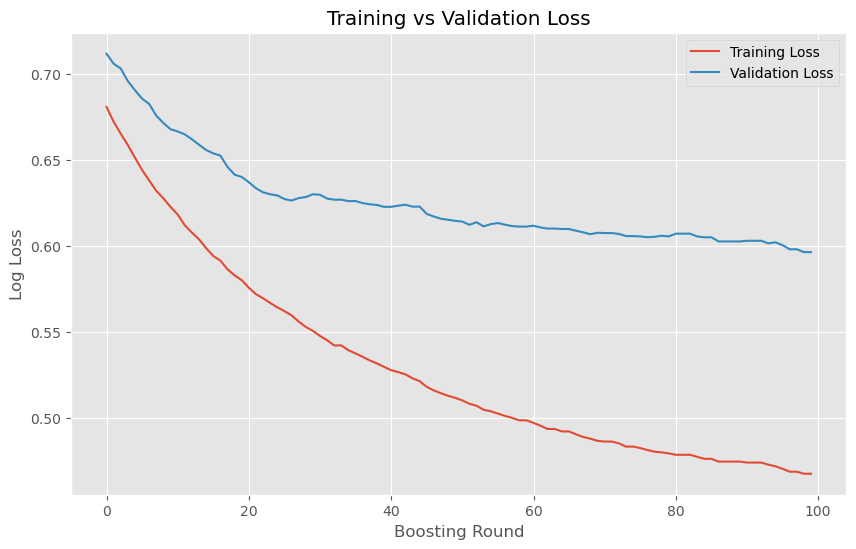

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


# LightGBM

In [79]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    colsample_bytree=0.6,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=500,
    num_leaves=31,
    subsample=0.6,
    lambda_l1=10.0,
    lambda_l2=20.0,
    min_child_weight=5,
    min_child_samples=20,
    feature_fraction=0.7,
    bagging_fraction=0.7,
    verbose = -1
    )

lgbm.fit(X_train, y_train, eval_set=eval_set, eval_metric='binary_logloss')

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,5
,min_child_samples,20


In [80]:
results = lgbm.evals_result_
print(results.keys())

train_loss = results['training']['binary_logloss']
val_loss = results['valid_1']['binary_logloss']

dict_keys(['training', 'valid_1'])


In [81]:
lgbm_pred = lgbm.predict(X_test)

acc = accuracy_score(y_test, lgbm_pred)
prec = precision_score(y_test, lgbm_pred)

print(f"Accuracy: {acc:.2%}")
print(f"Precision: {prec:.2%}")

Accuracy: 64.71%
Precision: 62.50%


In [82]:
print(classification_report(y_test, lgbm_pred))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67        18
           1       0.62      0.62      0.62        16

    accuracy                           0.65        34
   macro avg       0.65      0.65      0.65        34
weighted avg       0.65      0.65      0.65        34



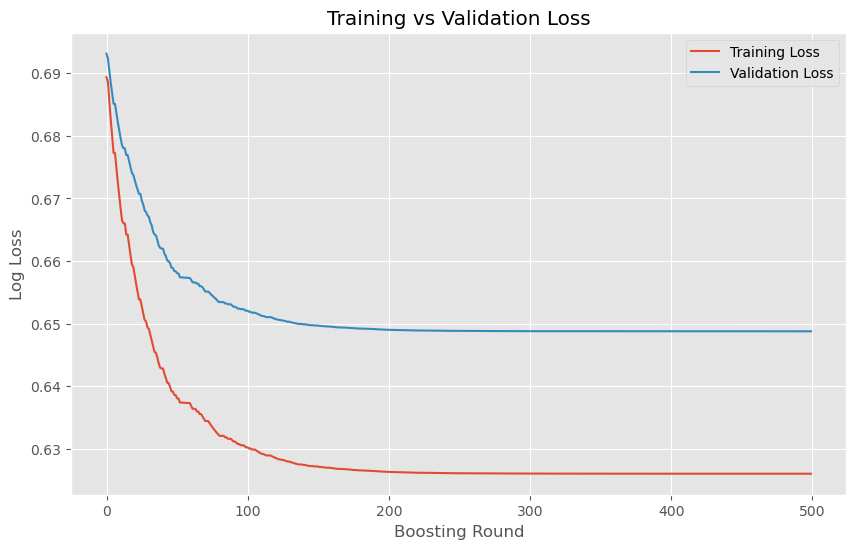

In [83]:
plt.figure(figsize=(10,6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

### GridSearchCV

In [ ]:
param_grid = {
    'max_depth': [6, 7, 8, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'min_child_samples': [20, 30, 35]
}

gs = GridSearchCV(lgbm, param_grid, scoring='neg_mean_squared_error', cv = 5, verbose=0)
gs.fit(X_train, y_train)

In [ ]:
print(gs.best_params_)

# Model Testing

In [ ]:
# Assuming your classes are ordered [Away Win (-1), Draw (0), Home Win (1)]
# Select a random row from the test set
sample_input = X_test.sample(n=1, random_state=42)

actual_outcome = y_test.loc[sample_input.index].values[0]

# Get the probability for each classifier
lgbm_prediction = lgbm.predict_proba(sample_input)[0]
xgb_prediction = xgb.predict_proba(sample_input)[0]
rf_prediction = clf.predict_proba(sample_input)[0]

# Convert the encoded team IDs back to team names
home_team_name = label_encoder.inverse_transform(sample_input['Home Team'].values.reshape(1))[0]
away_team_name = label_encoder.inverse_transform(sample_input['Away Team'].values.reshape(1))[0]

In [108]:
classes = label_encoder.classes_

def format_probs(probs):
    return {classes[i]: f"{p:.2%}" for i, p in enumerate(probs)}

print(f"Match Analysis: {home_team_name} vs {away_team_name}")
print(f"Actual Outcome: {actual_outcome}")
print("-" * 30)
print(f"Random Forest Confidence: {format_probs(rf_prediction)}")
print(f"LightGBM Confidence: {format_probs(lgbm_prediction)}")
print(f"XGBoost Confidence: {format_probs(xgb_prediction)}")

Match Analysis: Aston Villa vs Arsenal
Actual Outcome: 0
------------------------------
Random Forest Confidence: {'Arsenal': '57.92%', 'Aston Villa': '42.08%'}
LightGBM Confidence: {'Arsenal': '58.92%', 'Aston Villa': '41.08%'}
XGBoost Confidence: {'Arsenal': '53.57%', 'Aston Villa': '46.43%'}


# Model deployment Preparation

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import joblib

categorical_features = ["Home Team", "Away Team"]
numeric_features = [
    "avg_shot_diff",
    "avg_goal_diff",
    "avg_possess_diff",
    "home_goal_chances",
    "away_goal_chances",
    "home_rolling_avg_xG",
    "away_rolling_avg_xG"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features), # (name of transformer block, what transformation to apply, which column to apply)
        ("num", "passthrough", numeric_features) # Leaves numerical features as they are
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lgbm)
])

pipeline.fit(X, y)

joblib.dump(pipeline, "full_pipeline.pkl")


['full_pipeline.pkl']

In [86]:
joblib.dump(predictors, "feature_columns.pkl")

['feature_columns.pkl']